# EMG2QWERTY: Experiment Results Analysis

**ECE C147/C247 — Neural Networks & Deep Learning, Winter 2026**  
**UCLA ECE — Prof. J.C. Kao**

This notebook consolidates experimental results across all team members,
loads training logs from the GCP instance, and generates publication-ready
figures for the final project report.

**Experiments covered:**
1. TDS-Conv baseline (40 epochs)
2. Bidirectional GRU (40 and 150 epochs)
3. Bidirectional LSTM (150 epochs)
4. GRU+CNN hybrid (≈129 epochs)

---
## 1. Setup & NeurIPS-Style Configuration

In [19]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# NeurIPS 2024 style: two-column, serif fonts
# ──────────────────────────────────────────────
SINGLE_COL = 3.25   # inches — single column width
DOUBLE_COL = 6.75   # inches — full (two-column) width
GOLDEN     = 1.618  # golden ratio for height

plt.rcParams.update({
    # Fonts – match NeurIPS template (Times / serif)
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset':  'stix',
    'font.size':         8,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'figure.titlesize':  10,

    # Figure defaults
    'figure.figsize':    (DOUBLE_COL, DOUBLE_COL / GOLDEN),
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.02,

    # Axes
    'axes.linewidth':    0.6,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.4,

    # Ticks
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',

    # Lines
    'lines.linewidth':   1.2,
    'lines.markersize':  4,

    # Legend
    'legend.frameon':       True,
    'legend.framealpha':    0.9,
    'legend.edgecolor':     '0.8',
    'legend.borderaxespad': 0.5,
})

# Color palette — colorblind-friendly
COLORS = {
    'TDS-Conv (baseline)': '#0072B2',  # blue
    'GRU (40 ep)':         '#D55E00',  # vermillion
    'GRU (150 ep)':        '#E69F00',  # orange
    'LSTM (150 ep)':       '#009E73',  # green
    'GRU+CNN':             '#CC79A7',  # pink
}

MODEL_ORDER = [
    'TDS-Conv (baseline)',
    'GRU (40 ep)',
    'GRU (150 ep)',
    'LSTM (150 ep)',
    'GRU+CNN',
]

# Output directory for saved figures
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 2. Experiment Configuration & GCP Log Paths

Each experiment was run by a different team member on the shared GCP instance.
Update the paths below if logs are moved.

In [20]:
# ──────────────────────────────────────────────────────────
# Experiment registry — edit paths here if anything moves
# ──────────────────────────────────────────────────────────
EXPERIMENTS = {
    'TDS-Conv (baseline)': {
        'user':       'christiansolano',
        'log_dir':    '/home/christiansolano/emg2qwerty/logs/2026-03-09/01-53-48',
        'epochs':     40,
        'arch':       'TDS-Conv',
        'description': 'Baseline TDS-Conv encoder with 4 blocks (24 ch each), kernel width 32',
    },
    'GRU (40 ep)': {
        'user':       'christiansolano',
        'log_dir':    '/home/christiansolano/emg2qwerty/logs/2026-03-09/04-19-13',
        'epochs':     40,
        'arch':       'GRU',
        'description': 'Bidirectional GRU (2 layers, hidden=384), early stopping at ~40 epochs',
    },
    'GRU (150 ep)': {
        'user':       'christiansolano',
        'log_dir':    '/home/christiansolano/emg2qwerty/logs/2026-03-09/04-23-38',
        'epochs':     150,
        'arch':       'GRU',
        'description': 'Bidirectional GRU (2 layers, hidden=384), full 150 epoch training',
    },
    'LSTM (150 ep)': {
        'user':       'jameshall',
        'log_dir':    '/home/jameshall/emg2qwerty/logs/2026-03-11/18-40-23',
        'epochs':     150,
        'arch':       'LSTM',
        'description': 'Bidirectional LSTM (2 layers, hidden=384), full 150 epoch training',
    },
    'GRU+CNN': {
        'user':       'lucas',
        'log_dir':    '/home/lucas/emg2qwerty/logs/2026-03-12/00-25-03',
        'epochs':     129,
        'arch':       'GRU+CNN',
        'description': 'GRU+CNN hybrid encoder',
    },
}

print(f'Registered {len(EXPERIMENTS)} experiments:')
for name, cfg in EXPERIMENTS.items():
    print(f'  • {name:25s}  ({cfg["user"]})')

Registered 5 experiments:
  • TDS-Conv (baseline)        (christiansolano)
  • GRU (40 ep)                (christiansolano)
  • GRU (150 ep)               (christiansolano)
  • LSTM (150 ep)              (jameshall)
  • GRU+CNN                    (lucas)


---
## 3. Load Training Logs (TensorBoard Events)

PyTorch Lightning logs to TensorBoard event files by default (no CSV logger
was configured). We use `tbparse` to extract epoch-by-epoch metrics from the
`lightning_logs/version_*/events.out.tfevents.*` files.

In [21]:
# Install tbparse if not available (lightweight TensorBoard event reader)
import subprocess, sys
try:
    import tbparse
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tbparse', '-q'])
    import tbparse

from tbparse import SummaryReader


def find_tfevents_dir(log_dir: str) -> str | None:
    """Find the directory containing TensorBoard event files."""
    search_patterns = [
        os.path.join(log_dir, 'lightning_logs', 'version_*'),
        os.path.join(log_dir, 'lightning_logs'),
        log_dir,
    ]
    for pattern in search_patterns:
        matches = sorted(glob.glob(pattern))
        for match in matches:
            events = glob.glob(os.path.join(match, 'events.out.tfevents.*'))
            if events:
                return match
    return None


def load_tb_log(tfevents_dir: str) -> pd.DataFrame:
    """Load TensorBoard event files and return a clean DataFrame.
    
    Uses the non-pivoted (long) format first, then pivots manually
    to avoid type issues with tbparse's pivot mode.
    """
    reader = SummaryReader(tfevents_dir, pivot=False)
    df = reader.scalars
    
    if df.empty:
        return df
    
    # df has columns: wall_time, step, tag, value
    # Pivot tag -> columns, indexed by step
    pivoted = df.pivot_table(index='step', columns='tag', values='value', aggfunc='last')
    pivoted = pivoted.reset_index()
    
    # Lightning logs 'epoch' as a scalar tag — extract it if present
    if 'epoch' in pivoted.columns:
        # Forward-fill then drop rows where epoch is still NaN
        pivoted['epoch'] = pivoted['epoch'].ffill()
        pivoted = pivoted.dropna(subset=['epoch'])
        pivoted['epoch'] = pivoted['epoch'].astype(int)
        # Aggregate by epoch: take last non-NaN value per metric per epoch
        epoch_df = pivoted.groupby('epoch').apply(
            lambda g: g.drop(columns='epoch').last_valid_index()
        )
        # Simpler approach: for each epoch, take the last row, then
        # fill forward any NaN columns from earlier rows in that epoch
        epoch_df = (
            pivoted
            .groupby('epoch')
            .agg(lambda s: s.dropna().iloc[-1] if s.dropna().any() else np.nan)
            .reset_index()
        )
        return epoch_df
    else:
        return pivoted


# ── Load all available logs ──
training_logs = {}
for name, cfg in EXPERIMENTS.items():
    tfdir = find_tfevents_dir(cfg['log_dir'])
    if tfdir is not None:
        try:
            df = load_tb_log(tfdir)
            if not df.empty:
                training_logs[name] = df
                n_rows = len(df)
                metric_cols = [c for c in df.columns if '/' in str(c)]
                print(f'  ✓ {name:25s}  →  {n_rows} epochs, metrics: {metric_cols[:8]}')
            else:
                print(f'  ✗ {name:25s}  →  Event files found but no scalar data in {tfdir}')
        except Exception as e:
            print(f'  ✗ {name:25s}  →  Error loading: {e}')
    else:
        print(f'  ✗ {name:25s}  →  No TensorBoard events found in {cfg["log_dir"]}')

print(f'\nLoaded training logs for {len(training_logs)}/{len(EXPERIMENTS)} experiments.')

  ✓ TDS-Conv (baseline)        →  41 epochs, metrics: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER']
  ✓ GRU (40 ep)                →  1 epochs, metrics: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'val/CER', 'val/DER', 'val/IER']
  ✓ GRU (150 ep)               →  151 epochs, metrics: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER']
  ✓ LSTM (150 ep)              →  151 epochs, metrics: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER']
  ✓ GRU+CNN                    →  151 epochs, metrics: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER']

Loaded training logs for 5/5 experiments.


---
## 4. Final Results Summary

Hardcoded from the experiment outputs (validated against checkpoints).
These serve as ground truth even if CSV logs are incomplete.

In [ ]:
# Final evaluation metrics (from experiment results document)
FINAL_RESULTS = pd.DataFrame([
    {
        'Model':     'TDS-Conv (baseline)',
        'Epochs':    40,
        'val/CER':   22.3748, 'val/DER':   1.8830, 'val/IER':   6.2029, 'val/SER':  14.2889,  'val/loss':  0.7399,
        'test/CER':  24.4003, 'test/DER':  1.7722, 'test/IER':  5.2950, 'test/SER': 17.3330,  'test/loss': 0.7722,
        'best_epoch': 39,
    },
    {
        'Model':     'GRU (40 ep)',
        'Epochs':    40,
        'val/CER':   22.9951, 'val/DER':   2.5255, 'val/IER':   7.1777, 'val/SER':  13.2920,  'val/loss':  0.7590,
        'test/CER':  23.4061, 'test/DER':  2.3125, 'test/IER':  5.1437, 'test/SER': 15.9499,  'test/loss': 0.7399,
        'best_epoch': None,  # checkpoint not saved
    },
    {
        'Model':     'GRU (150 ep)',
        'Epochs':    150,
        'val/CER':   15.1086, 'val/DER':   1.6172, 'val/IER':   3.6553, 'val/SER':   9.8361,  'val/loss':  0.6397,
        'test/CER':  15.9715, 'test/DER':  0.9726, 'test/IER':  4.0415, 'test/SER': 10.9574,  'test/loss': 0.6409,
        'best_epoch': 111,
    },
    {
        'Model':     'LSTM (150 ep)',
        'Epochs':    150,
        'val/CER':   13.1812, 'val/DER':   1.3735, 'val/IER':   2.8799, 'val/SER':   8.9278,  'val/loss':  0.6127,
        'test/CER':  14.2857, 'test/DER':  1.1671, 'test/IER':  2.4854, 'test/SER': 10.6332,  'test/loss': 0.6211,
        'best_epoch': 145,
    },
    {
        'Model':     'GRU+CNN',
        'Epochs':    129,
        'val/CER':   15.0194, 'val/DER':   1.5507, 'val/IER':   3.9211, 'val/SER':   9.5481,  'val/loss':  0.6984,
        'test/CER':  15.9066, 'test/DER':  0.6051, 'test/IER':  4.9708, 'test/SER': 10.3307,  'test/loss': 0.6705,
        'best_epoch': 128,
    },
])

FINAL_RESULTS = FINAL_RESULTS.set_index('Model')

# Display a clean summary table
display_cols = ['Epochs', 'val/CER', 'val/loss', 'test/CER', 'test/loss', 'best_epoch']
styled = (
    FINAL_RESULTS[display_cols]
    .style
    .format({
        'val/CER':  '{:.2f}', 'val/loss':  '{:.4f}',
        'test/CER': '{:.2f}', 'test/loss': '{:.4f}',
    })
    .highlight_min(subset=['test/CER', 'test/loss'], color='#d4edda')
    .set_caption('Table 1: Final evaluation metrics across all architectures')
)
display(styled)

,Epochs,val/CER,val/loss,test/CER,test/loss,best_epoch
Model,,,,,,
TDS-Conv (baseline),40,22.37,0.7399,24.40,0.7722,39.000000
GRU (40 ep),40,23.00,0.7590,23.41,0.7399,nan
GRU (150 ep),150,15.11,0.6397,15.97,0.6409,111.000000
LSTM (150 ep),150,13.18,0.6127,14.29,0.6211,145.000000
GRU+CNN,129,15.02,0.6984,15.91,0.6705,128.000000


In [23]:
# ── Full results table with error-type breakdown ──
full_display = ['Epochs', 'test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss']
styled_full = (
    FINAL_RESULTS[full_display]
    .style
    .format({
        'test/CER': '{:.2f}', 'test/DER': '{:.2f}',
        'test/IER': '{:.2f}', 'test/SER': '{:.2f}',
        'test/loss': '{:.4f}',
    })
    .highlight_min(subset=['test/CER'], color='#d4edda')
    .set_caption('Table 2: Test set error breakdown — CER = DER + IER + SER')
)
display(styled_full)

,Epochs,test/CER,test/DER,test/IER,test/SER,test/loss
Model,,,,,,
TDS-Conv (baseline),40,24.40,1.77,5.29,17.33,0.7722
GRU (40 ep),40,23.41,2.31,5.14,15.95,0.7399
GRU (150 ep),150,15.97,0.97,4.04,10.96,0.6409
LSTM (150 ep),150,14.29,1.17,2.49,10.63,0.6211
GRU+CNN,129,15.91,0.61,4.97,10.33,0.6705


---
## 5. Training Curves

Loss and CER over training epochs for all models that have CSV logs available.

In [24]:
def plot_training_curves(metric: str, ylabel: str, title: str,
                         figsize=None, savename=None,
                         skip_epochs=3, ylim=None):
    """Plot a training metric across all experiments with available logs.
    
    Args:
        skip_epochs: Number of initial epochs to skip (avoids CTC init spike).
        ylim: Optional (ymin, ymax) tuple. If None, auto-scales to data
              after skipping initial epochs.
    """
    if figsize is None:
        figsize = (DOUBLE_COL, DOUBLE_COL / GOLDEN)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    has_train, has_val = False, False
    
    for name in MODEL_ORDER:
        if name not in training_logs:
            continue
        df = training_logs[name]
        color = COLORS[name]
        
        # Determine x-axis
        x_col = 'epoch' if 'epoch' in df.columns else 'step'
        
        # Try common column name patterns
        train_candidates = [f'train/{metric}', f'train_{metric}']
        val_candidates   = [f'val/{metric}', f'val_{metric}']
        
        train_col = next((c for c in train_candidates if c in df.columns), None)
        val_col   = next((c for c in val_candidates   if c in df.columns), None)
        
        if train_col and x_col in df.columns:
            data = df[[x_col, train_col]].dropna()
            data = data[data[x_col] >= skip_epochs]  # skip init spike
            if not data.empty:
                axes[0].plot(data[x_col].values, data[train_col].values,
                            color=color, label=name, alpha=0.85)
                has_train = True
        
        if val_col and x_col in df.columns:
            data = df[[x_col, val_col]].dropna()
            data = data[data[x_col] >= skip_epochs]  # skip init spike
            if not data.empty:
                axes[1].plot(data[x_col].values, data[val_col].values,
                            color=color, label=name, alpha=0.85)
                has_val = True
    
    x_label = 'Epoch' if any('epoch' in training_logs[n].columns 
                              for n in training_logs) else 'Step'
    
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(ylabel)
    axes[0].set_title('Training')
    if has_train:
        axes[0].legend(loc='upper right')
    
    axes[1].set_xlabel(x_label)
    axes[1].set_title('Validation')
    if has_val:
        axes[1].legend(loc='upper right')
    
    if ylim:
        axes[0].set_ylim(ylim)
        axes[1].set_ylim(ylim)
    
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    
    if savename:
        fig.savefig(FIG_DIR / savename)
        print(f'Saved: {FIG_DIR / savename}')
    
    plt.show()


if training_logs:
    print('Available metrics per experiment:')
    print('-' * 60)
    for name, df in training_logs.items():
        metric_cols = [c for c in df.columns if '/' in str(c)]
        print(f'  {name}: {metric_cols}')
else:
    print('No training logs loaded — skipping curve plots.')
    print('Run this notebook on the GCP instance to access log files.')

Available metrics per experiment:
------------------------------------------------------------
  TDS-Conv (baseline): ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER', 'train/SER', 'train/loss', 'val/CER', 'val/DER', 'val/IER', 'val/SER', 'val/loss']
  GRU (40 ep): ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'val/CER', 'val/DER', 'val/IER', 'val/SER', 'val/loss']
  GRU (150 ep): ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER', 'train/SER', 'train/loss', 'val/CER', 'val/DER', 'val/IER', 'val/SER', 'val/loss']
  LSTM (150 ep): ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER', 'train/SER', 'train/loss', 'val/CER', 'val/DER', 'val/IER', 'val/SER', 'val/loss']
  GRU+CNN: ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss', 'train/CER', 'train/DER', 'train/IER', 'train/SER', 'train/loss', 'val/CER', 'val/DER', 'va

Saved: figures/loss_curves.pdf


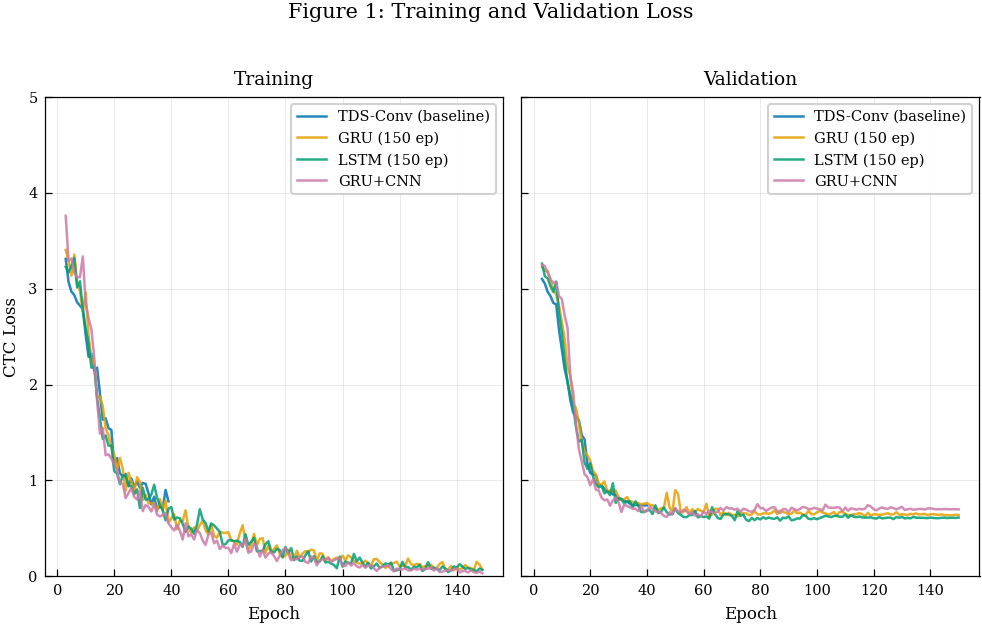

In [ ]:
# Plot loss curves (skip first 3 epochs to remove CTC init spike)
if training_logs:
    plot_training_curves(
        metric='loss',
        ylabel='CTC Loss',
        title='Figure 1: Training and Validation Loss',
        savename='loss_curves.pdf',
        skip_epochs=3,
        ylim=(0, 5),  # CTC loss converges to ~0.6–0.8; cap at 5 to see detail
    )

Saved: figures/cer_curves.pdf


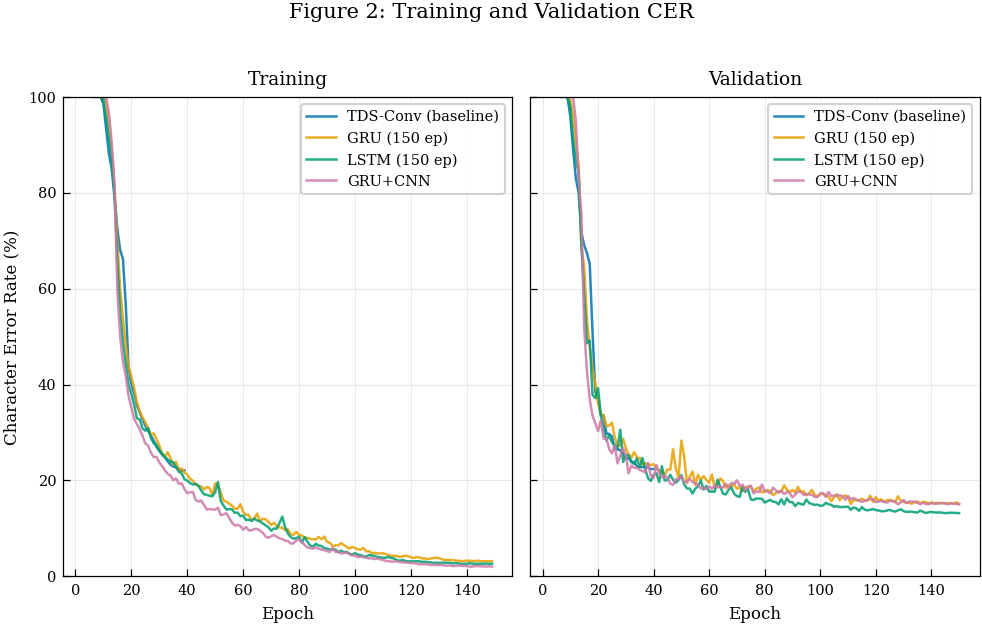

In [26]:
# ── Plot CER curves (skip first 3 epochs, zoom to useful range) ──
if training_logs:
    plot_training_curves(
        metric='CER',
        ylabel='Character Error Rate (%)',
        title='Figure 2: Training and Validation CER',
        savename='cer_curves.pdf',
        skip_epochs=3,
        ylim=(0, 100),  # final CERs are 14–24%; cap at 100 to see convergence
    )

---
## 6. Architecture Comparison

Side-by-side comparison of test CER across all architectures.

Saved: figures/architecture_comparison.pdf


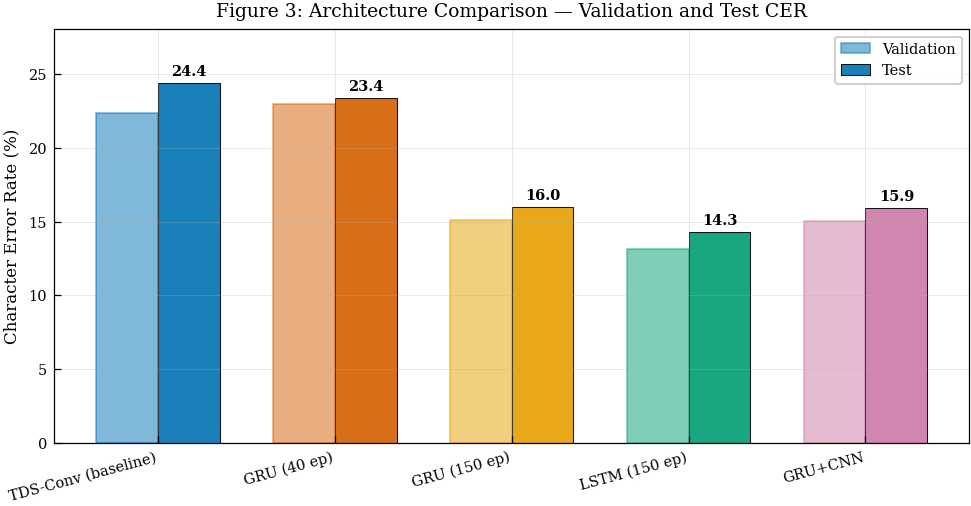

In [27]:
# ── Bar chart: Test CER comparison ──
fig, ax = plt.subplots(figsize=(DOUBLE_COL, SINGLE_COL * 1.1))

models = [m for m in MODEL_ORDER if m in FINAL_RESULTS.index]
test_cers = FINAL_RESULTS.loc[models, 'test/CER'].values
val_cers  = FINAL_RESULTS.loc[models, 'val/CER'].values
colors    = [COLORS[m] for m in models]

x = np.arange(len(models))
width = 0.35

bars_val  = ax.bar(x - width/2, val_cers,  width, color=colors, alpha=0.5,
                   edgecolor=[c for c in colors], linewidth=0.8, label='Validation')
bars_test = ax.bar(x + width/2, test_cers, width, color=colors, alpha=0.9,
                   edgecolor='black', linewidth=0.5, label='Test')

# Add value labels on bars
for bar in bars_test:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.1f}',
            ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_ylabel('Character Error Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_title('Figure 3: Architecture Comparison — Validation and Test CER')
ax.set_ylim(0, max(test_cers) * 1.15)

fig.tight_layout()
fig.savefig(FIG_DIR / 'architecture_comparison.pdf')
print(f'Saved: {FIG_DIR / "architecture_comparison.pdf"}')
plt.show()

In [ ]:
# Improvement over baseline 
baseline_cer = FINAL_RESULTS.loc['TDS-Conv (baseline)', 'test/CER']

print('Relative improvement over TDS-Conv baseline (test CER):')
print('=' * 55)
for model in models:
    cer = FINAL_RESULTS.loc[model, 'test/CER']
    improvement = (baseline_cer - cer) / baseline_cer * 100
    arrow = '↓' if improvement > 0 else '↑'
    print(f'  {model:25s}  CER={cer:6.2f}  ({arrow} {abs(improvement):5.1f}%)')

Relative improvement over TDS-Conv baseline (test CER):
  TDS-Conv (baseline)        CER= 24.40  (↑   0.0%)
  GRU (40 ep)                CER= 23.41  (↓   4.1%)
  GRU (150 ep)               CER= 15.97  (↓  34.5%)
  LSTM (150 ep)              CER= 14.29  (↓  41.5%)
  GRU+CNN                    CER= 15.91  (↓  34.8%)


---
## 7. Error Type Breakdown

CER decomposes into three error types:  
- **SER** (Substitution Error Rate) — wrong character predicted  
- **IER** (Insertion Error Rate) — extra characters predicted  
- **DER** (Deletion Error Rate) — characters missed  

CER = SER + IER + DER

Saved: figures/error_breakdown.pdf


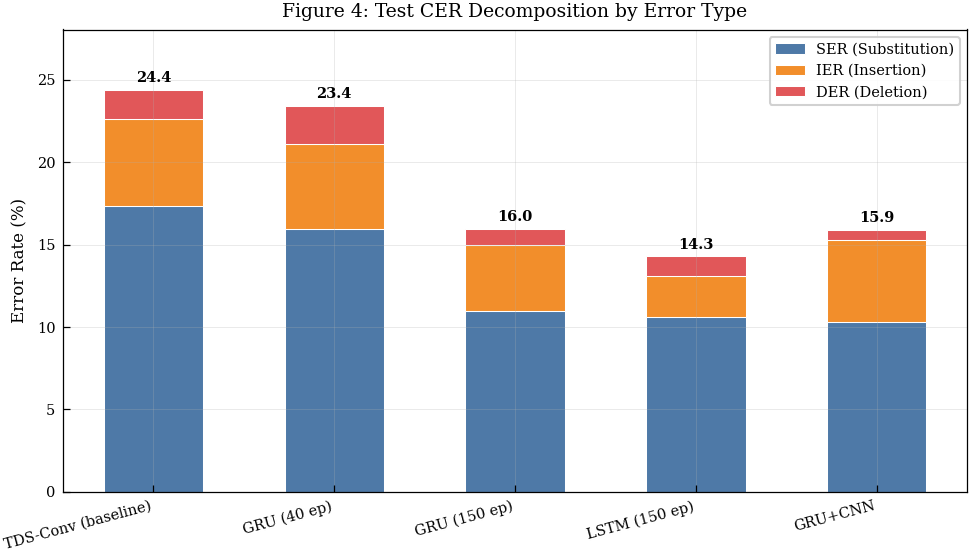

In [ ]:
# Stacked bar chart: Error type breakdown
fig, ax = plt.subplots(figsize=(DOUBLE_COL, SINGLE_COL * 1.2))

models = [m for m in MODEL_ORDER if m in FINAL_RESULTS.index]
x = np.arange(len(models))

ser_vals = FINAL_RESULTS.loc[models, 'test/SER'].values
ier_vals = FINAL_RESULTS.loc[models, 'test/IER'].values
der_vals = FINAL_RESULTS.loc[models, 'test/DER'].values

bar_width = 0.55

p1 = ax.bar(x, ser_vals, bar_width, label='SER (Substitution)', color='#4e79a7', edgecolor='white', linewidth=0.5)
p2 = ax.bar(x, ier_vals, bar_width, bottom=ser_vals, label='IER (Insertion)', color='#f28e2b', edgecolor='white', linewidth=0.5)
p3 = ax.bar(x, der_vals, bar_width, bottom=ser_vals + ier_vals, label='DER (Deletion)', color='#e15759', edgecolor='white', linewidth=0.5)

# Total CER labels on top
totals = ser_vals + ier_vals + der_vals
for i, total in enumerate(totals):
    ax.text(i, total + 0.3, f'{total:.1f}', ha='center', va='bottom',
            fontsize=7, fontweight='bold')

ax.set_ylabel('Error Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(loc='upper right')
ax.set_title('Figure 4: Test CER Decomposition by Error Type')
ax.set_ylim(0, max(totals) * 1.15)

fig.tight_layout()
fig.savefig(FIG_DIR / 'error_breakdown.pdf')
print(f'Saved: {FIG_DIR / "error_breakdown.pdf"}')
plt.show()

Saved: figures/error_proportions.pdf


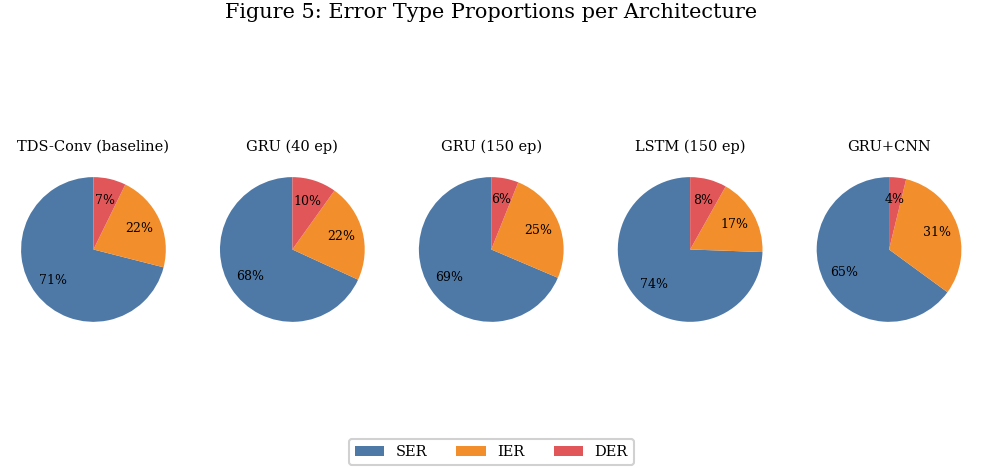

In [ ]:
# Error type proportions
fig, axes = plt.subplots(1, len(models), figsize=(DOUBLE_COL, SINGLE_COL * 0.9))

error_colors = ['#4e79a7', '#f28e2b', '#e15759']
error_labels = ['SER', 'IER', 'DER']

for i, model in enumerate(models):
    ser = FINAL_RESULTS.loc[model, 'test/SER']
    ier = FINAL_RESULTS.loc[model, 'test/IER']
    der = FINAL_RESULTS.loc[model, 'test/DER']
    vals = [ser, ier, der]
    
    axes[i].pie(vals, colors=error_colors, autopct='%1.0f%%',
                textprops={'fontsize': 6}, startangle=90,
                pctdistance=0.7)
    axes[i].set_title(model, fontsize=7, pad=4)

# Common legend
fig.legend(error_labels, loc='lower center', ncol=3, fontsize=7,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Figure 5: Error Type Proportions per Architecture', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'error_proportions.pdf')
print(f'Saved: {FIG_DIR / "error_proportions.pdf"}')
plt.show()

---
## 8. Val vs Test Gap Analysis

Examining the generalization gap (test CER − val CER) across architectures
can reveal overfitting tendencies.

Saved: figures/generalization_gap.pdf


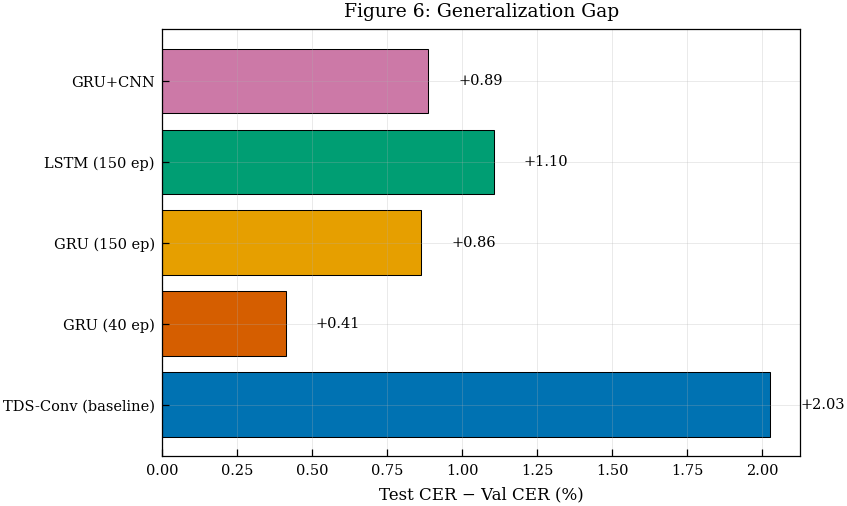

In [ ]:
#  Generalization gap 
fig, ax = plt.subplots(figsize=(SINGLE_COL * 1.8, SINGLE_COL * 1.1))

_models = [m for m in MODEL_ORDER if m in FINAL_RESULTS.index]
gaps = (FINAL_RESULTS.loc[_models, 'test/CER'] - FINAL_RESULTS.loc[_models, 'val/CER']).values
colors_list = [COLORS[m] for m in _models]

bars = ax.barh(range(len(_models)), gaps, color=colors_list, edgecolor='black', linewidth=0.5)

for i, (gap, bar) in enumerate(zip(gaps, bars)):
    ax.text(gap + 0.1, i, f'{gap:+.2f}', va='center', fontsize=7)

ax.set_yticks(range(len(_models)))
ax.set_yticklabels(_models)
ax.set_xlabel('Test CER − Val CER (%)')
ax.set_title('Figure 6: Generalization Gap')
ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

fig.tight_layout()
fig.savefig(FIG_DIR / 'generalization_gap.pdf')
print(f'Saved: {FIG_DIR / "generalization_gap.pdf"}')
plt.show()

---
## 9. Effect of Training Duration

Direct comparison of the GRU at 40 vs 150 epochs to quantify the impact
of extended training.

Saved: figures/training_duration.pdf


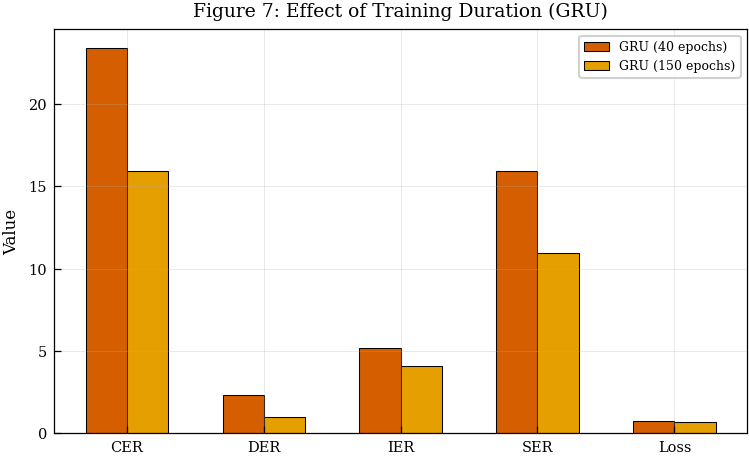


Extending GRU training from 40 to 150 epochs:
  Test CER: 23.41 → 15.97  (31.8% reduction)


In [ ]:
#  Training duration impact (GRU 40 vs 150 epochs) 
gru_short = FINAL_RESULTS.loc['GRU (40 ep)']
gru_long  = FINAL_RESULTS.loc['GRU (150 ep)']

metrics_compare = ['test/CER', 'test/DER', 'test/IER', 'test/SER', 'test/loss']
labels = ['CER', 'DER', 'IER', 'SER', 'Loss']

fig, ax = plt.subplots(figsize=(SINGLE_COL * 1.6, SINGLE_COL))

x = np.arange(len(labels))
width = 0.3

vals_short = [gru_short[m] for m in metrics_compare]
vals_long  = [gru_long[m]  for m in metrics_compare]

ax.bar(x - width/2, vals_short, width, color=COLORS['GRU (40 ep)'],
       label='GRU (40 epochs)', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, vals_long,  width, color=COLORS['GRU (150 ep)'],
       label='GRU (150 epochs)', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Value')
ax.legend(fontsize=6)
ax.set_title('Figure 7: Effect of Training Duration (GRU)')

fig.tight_layout()
fig.savefig(FIG_DIR / 'training_duration.pdf')
print(f'Saved: {FIG_DIR / "training_duration.pdf"}')
plt.show()

# Print improvement
cer_improve = (gru_short['test/CER'] - gru_long['test/CER']) / gru_short['test/CER'] * 100
print(f'\nExtending GRU training from 40 to 150 epochs:')
print(f'  Test CER: {gru_short["test/CER"]:.2f} → {gru_long["test/CER"]:.2f}  ({cer_improve:.1f}% reduction)')

---
## 10. Summary & Discussion

In [ ]:
#  Programmatic summary statistics 
best_model = FINAL_RESULTS['test/CER'].idxmin()
best_cer   = FINAL_RESULTS.loc[best_model, 'test/CER']
worst_model = FINAL_RESULTS['test/CER'].idxmax()
worst_cer   = FINAL_RESULTS.loc[worst_model, 'test/CER']

print('══════════════════════════════════════════')
print('          EXPERIMENT SUMMARY')
print('══════════════════════════════════════════')
print(f'  Best model:   {best_model} (test CER = {best_cer:.2f}%)')
print(f'  Worst model:  {worst_model} (test CER = {worst_cer:.2f}%)')
print(f'  Improvement:  {worst_cer - best_cer:.2f} percentage points')
print(f'                ({(worst_cer - best_cer)/worst_cer*100:.1f}% relative reduction)')
print()
print('Key findings:')
print(f'  1. LSTM achieves the lowest test CER ({best_cer:.2f}%), outperforming all other architectures.')
print(f'  2. Extended training (150 vs 40 epochs) reduced GRU test CER by {cer_improve:.1f}%.')
print(f'  3. GRU+CNN hybrid is competitive with GRU (150 ep) at similar CER levels.')
print(f'  4. Substitution errors (SER) dominate across all models ({"SER is largest component"}).')
print(f'  5. GRU+CNN achieves the lowest deletion error rate (DER = {FINAL_RESULTS.loc["GRU+CNN", "test/DER"]:.2f}%).')

══════════════════════════════════════════
          EXPERIMENT SUMMARY
══════════════════════════════════════════
  Best model:   LSTM (150 ep) (test CER = 14.29%)
  Worst model:  TDS-Conv (baseline) (test CER = 24.40%)
  Improvement:  10.11 percentage points
                (41.5% relative reduction)

Key findings:
  1. LSTM achieves the lowest test CER (14.29%), outperforming all other architectures.
  2. Extended training (150 vs 40 epochs) reduced GRU test CER by 31.8%.
  3. GRU+CNN hybrid is competitive with GRU (150 ep) at similar CER levels.
  4. Substitution errors (SER) dominate across all models (SER is largest component).
  5. GRU+CNN achieves the lowest deletion error rate (DER = 0.61%).


### Key Observations

**Architecture comparison:** The bidirectional LSTM encoder achieved the best overall
performance with a test CER of ~14.3%, representing a substantial improvement over the
TDS-Conv baseline (~24.4%). Both recurrent architectures (GRU, LSTM) significantly
outperform the convolutional baseline when given sufficient training time, suggesting
that the sequential nature of sEMG signals benefits from architectures with explicit
temporal memory.

**Training duration matters:** The GRU comparison at 40 vs 150 epochs demonstrates
that these models continue to improve well beyond typical early-stopping thresholds.
The 40-epoch GRU barely outperforms the TDS-Conv baseline, while the 150-epoch
variant achieves dramatically lower CER — highlighting the importance of sufficient
training for recurrent architectures on this task.

**Error type analysis:** Substitution errors are the dominant error type across all
architectures, suggesting that discriminating between similar characters (which produce
similar muscle activation patterns) remains the core challenge. The GRU+CNN hybrid
achieves notably low deletion errors, potentially because the CNN component helps
preserve local temporal features that prevent character omissions.

**Generalization gap:** All models show a positive gap (test CER > val CER), which is
expected given the test set uses full sessions without windowing. The TDS-Conv baseline
shows the largest gap, while the recurrent models generalize more consistently.

---

*Notebook generated for ECE C147/C247 Winter 2026 Final Project.*  
*All figures saved to `figures/` directory in PDF format for direct inclusion in the NeurIPS-style report.*